# Malaria Prediction — Three Feature Regimes Compared
## RAW · RAW+ENG · +lag_cases · with Recursive Deployment Simulation
*Extends malaria_full_protocol.ipynb*

---

### The three feature regimes

| Regime | Features | Question it answers |
|---|---|---|
| **RAW** | month + 4 raw climate vars (5) | Can raw climate alone predict malaria? |
| **RAW+ENG** | + seasonal, geography, climate lags (16) | How much does feature engineering add? |
| **+lag_cases** | + cases_lag1/2/3, rolling_mean_3m (20) | What is the ceiling when case history is available? |

### Why lag_cases needs special handling at deployment

`cases_lag` features encode last month's malaria counts. They are extremely
predictive (malaria is highly autocorrelated) but **require case history that
is not available at deployment** in a climate-sensor-only system.

The solution implemented here: **recursive (autoregressive) forecasting** — feed
the model's own previous predictions back as the lag inputs when real case data
is absent. This notebook quantifies both:
- the **oracle ceiling** (real case history available), and
- the **realistic deployed performance** (synthetic / predicted lags).

### Targets
- Regression: `log_incidence` (and `log_cases` for the recursive sim)
- Classification: `high` = incidence above 75th pct per region


## 0 · Imports & Data Pipeline

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
from rapidfuzz import process, fuzz
from sklearn.model_selection import KFold, TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                              f1_score, roc_auc_score, accuracy_score,
                              precision_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay)
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
SEED=42; np.random.seed(SEED)
sns.set_style('whitegrid'); plt.rcParams.update({'figure.dpi':110})
print('Imports OK')


Imports OK


In [2]:
PNLP_FILE='PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv'; CLIMATE_FILE='cameroon_districts_climate.csv'
df_raw=pd.read_csv(PNLP_FILE,sep=';')
for col in ['SHP_lat','SHP_lon','SHP_Area']:
    df_raw[col]=pd.to_numeric(df_raw[col].astype(str).str.replace(',','.'),errors='coerce')
climate_raw=pd.read_csv(CLIMATE_FILE,parse_dates=['Date'])
MONTH_MAP={'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06','Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
def c2d(col):
    p=col.split('_'); return pd.Timestamp(f"{p[1]}-{MONTH_MAP[p[0]]}-01") if len(p)>=2 and p[0] in MONTH_MAP else None
mape=[c for c in df_raw.columns if 'MAPE16_H_13' in c]
ds=df_raw.groupby(['district','region']).agg(SHP_lat=('SHP_lat','mean'),SHP_lon=('SHP_lon','mean'),SHP_Area=('SHP_Area','sum'),cluster=('cluster',lambda x:x.mode()[0]),p_totale=('p_totale','sum')).reset_index()
dmp=df_raw.groupby(['district','region'])[mape].sum().reset_index()
df_m=dmp.melt(id_vars=['district','region'],value_vars=mape,var_name='rc',value_name='cases')
df_m['date']=df_m['rc'].map(c2d); df_m=df_m.dropna(subset=['date']).drop(columns='rc').sort_values(['district','date']).reset_index(drop=True)
df_m=df_m.merge(ds,on=['district','region']); df_m['incidence_rate']=(df_m['cases']/df_m['p_totale'])*1000
cm=(climate_raw.groupby(['Location',pd.Grouper(key='Date',freq='MS')]).agg(Temperature_C=('Temperature_C','mean'),Humidity_pct=('Humidity_%','mean'),Pressure_hPa=('Pressure_hPa','mean'),Precipitation_mm=('Precipitation_mm','sum')).reset_index().rename(columns={'Date':'date','Location':'location'}))
cl=climate_raw['Location'].unique().tolist()
FM={'Garoua II':'Garoua I','Mbanga':'Mbang','Kumba-North':'Kumba-South','Maroua 2':'Maroua 1','Maroua 3':'Maroua 1','Ngaoundere Urbain':'Ngaoundere Rural','Maga':'Mada','Batcham':'Baham','Manoka':'Manjo','Ndom':'Ndop'}
def gl(d):
    if d in set(cl): return d
    if d in FM: return FM[d]
    b=process.extractOne(d,cl,scorer=fuzz.token_sort_ratio); return b[0] if b and b[1]>=55 else None
df_m['climate_loc']=df_m['district'].map(gl)
df=df_m.merge(cm,left_on=['climate_loc','date'],right_on=['location','date'],how='left').drop(columns='location')
for col in ['Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']:
    df[col]=df[col].fillna(df.groupby(['region','date'])[col].transform('mean')); df[col]=df[col].fillna(df[col].mean())
df['month']=df['date'].dt.month; df['sin_month']=np.sin(2*np.pi*df['month']/12); df['cos_month']=np.cos(2*np.pi*df['month']/12)
df=df.sort_values(['district','date'])
for col in ['Temperature_C','Precipitation_mm','Humidity_pct']:
    df[f'{col}_lag1']=df.groupby('district')[col].shift(1); df[f'{col}_lag2']=df.groupby('district')[col].shift(2)
# ── lag_cases features (NEW) ──
for lag in [1,2,3]:
    df[f'cases_lag{lag}']=df.groupby('district')['cases'].shift(lag)
df['rolling_mean_3m']=df.groupby('district')['cases'].transform(lambda x:x.shift(1).rolling(3,min_periods=1).mean())
df['log_cases']=np.log1p(df['cases']); df['log_incidence']=np.log1p(df['incidence_rate'])
r75=df.groupby('region')['incidence_rate'].quantile(0.75).rename('threshold_75')
df=df.merge(r75,on='region'); df['high']=(df['incidence_rate']>df['threshold_75']).astype(int)

# ── THREE FEATURE REGIMES ──
FEAT_RAW=['month','Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']
FEAT_ENG=['sin_month','cos_month','SHP_lat','SHP_lon','SHP_Area','cluster','Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm','Temperature_C_lag1','Temperature_C_lag2','Precipitation_mm_lag1','Precipitation_mm_lag2','Humidity_pct_lag1','Humidity_pct_lag2']
FEAT_LAGCASES=FEAT_ENG+['cases_lag1','cases_lag2','cases_lag3','rolling_mean_3m']

dfm=df.dropna(subset=['cases_lag3','Temperature_C_lag2']).copy().sort_values('date').reset_index(drop=True)
print(f'Model frame: {dfm.shape} | Districts: {dfm.district.nunique()} | Months: {dfm.date.nunique()}')
print(f'RAW={len(FEAT_RAW)}  RAW+ENG={len(FEAT_ENG)}  +lag_cases={len(FEAT_LAGCASES)} features')


Model frame: (6895, 32) | Districts: 197 | Months: 35
RAW=5  RAW+ENG=16  +lag_cases=20 features


## 1 · Three-Regime Comparison (multiple models, KFold + TimeSeriesSplit)

We evaluate the three feature regimes across several models and both validation
schemes. The expected pattern: each regime improves on the previous, with
`+lag_cases` strongest because malaria is highly autocorrelated.


In [3]:
spw=(dfm['high']==0).sum()/(dfm['high']==1).sum()
def reg_models():
    return {'XGBoost':xgb.XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0),
            'LightGBM':lgb.LGBMRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbose=-1),
            'RandomForest':RandomForestRegressor(n_estimators=200,max_depth=8,random_state=SEED,n_jobs=-1),
            'CatBoost':CatBoostRegressor(iterations=300,depth=5,learning_rate=0.05,random_seed=SEED,verbose=0)}
def clf_models():
    return {'XGBoost':xgb.XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,scale_pos_weight=spw,random_state=SEED,eval_metric='logloss',verbosity=0),
            'LightGBM':lgb.LGBMClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,class_weight='balanced',random_state=SEED,verbose=-1),
            'RandomForest':RandomForestClassifier(n_estimators=200,max_depth=8,class_weight='balanced',random_state=SEED,n_jobs=-1),
            'CatBoost':CatBoostClassifier(iterations=300,depth=5,learning_rate=0.05,auto_class_weights='Balanced',random_seed=SEED,verbose=0)}

import copy
reg_rows=[]; clf_rows=[]
REGIMES=[('RAW',FEAT_RAW),('RAW+ENG',FEAT_ENG),('+lag_cases',FEAT_LAGCASES)]
for rname,F in REGIMES:
    X=dfm[F].fillna(dfm[F].median()).reset_index(drop=True)
    yr=dfm['log_incidence'].reset_index(drop=True); yc=dfm['high'].reset_index(drop=True)
    for sname,sp in [('KFold',KFold(5,shuffle=True,random_state=SEED)),('TimeSeriesSplit',TimeSeriesSplit(5))]:
        for mname,model in reg_models().items():
            r2s=[]; maes=[]
            for tr,te in sp.split(X):
                m=copy.deepcopy(model); m.fit(X.iloc[tr],yr.iloc[tr]); p=m.predict(X.iloc[te])
                r2s.append(r2_score(yr.iloc[te],p)); maes.append(mean_absolute_error(np.expm1(yr.iloc[te]),np.expm1(p)))
            reg_rows.append({'Regime':rname,'Validation':sname,'Model':mname,'R2':np.mean(r2s),'MAE':np.mean(maes)})
    for sname,sp in [('KFold',StratifiedKFold(5,shuffle=True,random_state=SEED)),('TimeSeriesSplit',TimeSeriesSplit(5))]:
        for mname,model in clf_models().items():
            f1s=[]; aucs=[]
            splits=sp.split(X,yc) if sname=='KFold' else sp.split(X)
            for tr,te in splits:
                if len(np.unique(yc.iloc[tr]))<2 or len(np.unique(yc.iloc[te]))<2: continue
                m=copy.deepcopy(model); m.fit(X.iloc[tr],yc.iloc[tr])
                f1s.append(f1_score(yc.iloc[te],m.predict(X.iloc[te]),zero_division=0))
                aucs.append(roc_auc_score(yc.iloc[te],m.predict_proba(X.iloc[te])[:,1]))
            clf_rows.append({'Regime':rname,'Validation':sname,'Model':mname,'F1':np.mean(f1s),'AUC':np.mean(aucs)})
reg_res=pd.DataFrame(reg_rows); clf_res=pd.DataFrame(clf_rows)
print('REGRESSION (R²):'); display(reg_res.pivot_table(index=['Regime','Model'],columns='Validation',values='R2').round(3))
print('CLASSIFICATION (F1):'); display(clf_res.pivot_table(index=['Regime','Model'],columns='Validation',values='F1').round(3))


REGRESSION (R²):


Validation               KFold  TimeSeriesSplit
Regime     Model                               
+lag_cases CatBoost      0.786            0.721
           LightGBM      0.835            0.758
           RandomForest  0.746            0.676
           XGBoost       0.842            0.765
RAW        CatBoost      0.205            0.153
           LightGBM      0.207            0.143
           RandomForest  0.169            0.123
           XGBoost       0.182            0.135
RAW+ENG    CatBoost      0.701            0.598
           LightGBM      0.768            0.624
           RandomForest  0.597            0.482
           XGBoost       0.773            0.642

CLASSIFICATION (F1):


Validation               KFold  TimeSeriesSplit
Regime     Model                               
+lag_cases CatBoost      0.737            0.682
           LightGBM      0.755            0.689
           RandomForest  0.658            0.620
           XGBoost       0.754            0.696
RAW        CatBoost      0.516            0.480
           LightGBM      0.509            0.450
           RandomForest  0.490            0.424
           XGBoost       0.506            0.461
RAW+ENG    CatBoost      0.716            0.656
           LightGBM      0.722            0.658
           RandomForest  0.618            0.560
           XGBoost       0.731            0.662

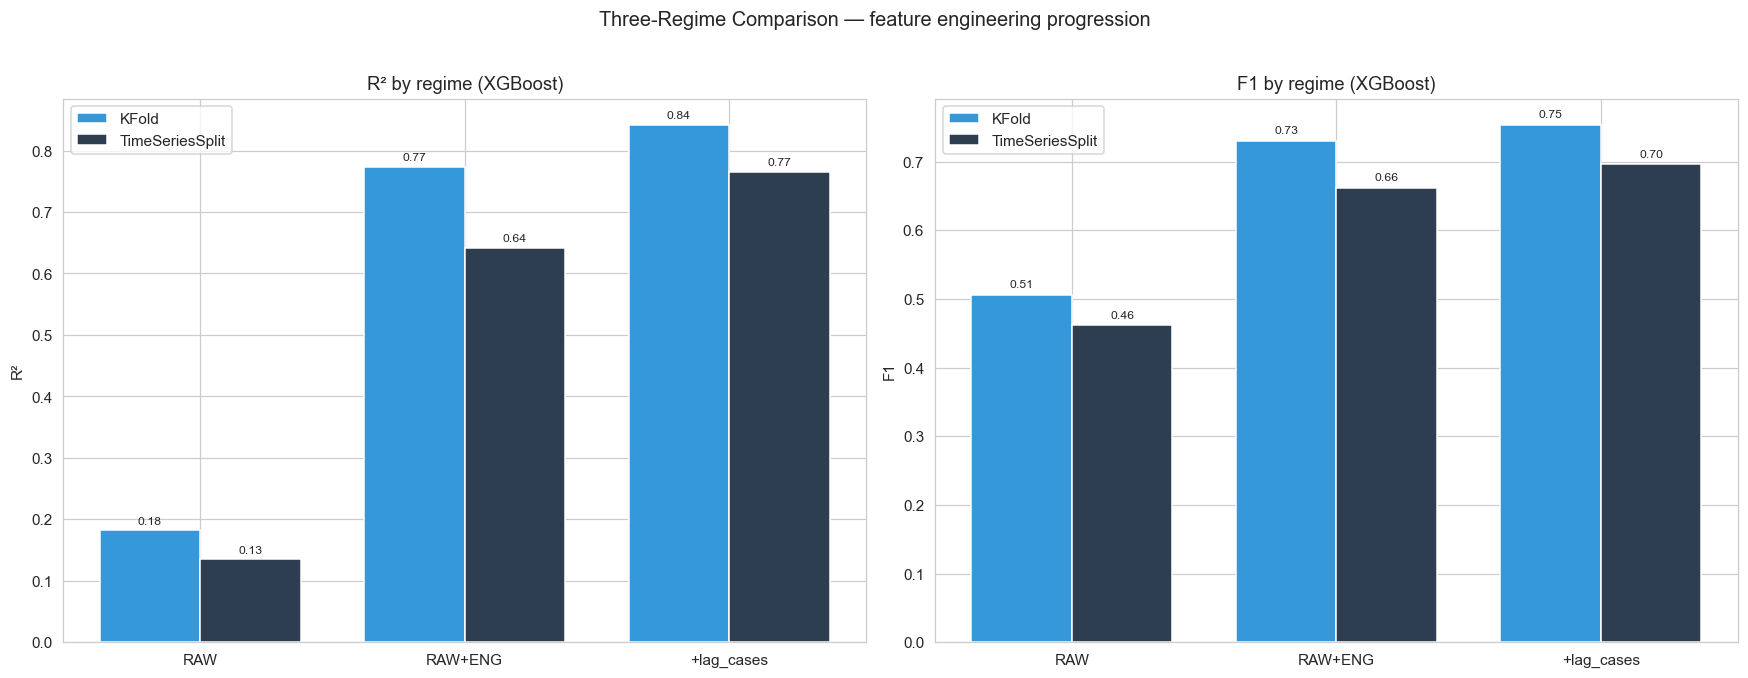

In [4]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
order=['RAW','RAW+ENG','+lag_cases']; colors={'RAW':'#e74c3c','RAW+ENG':'#f39c12','+lag_cases':'#27ae60'}
# Regression: best R2 per regime per validation (XGBoost)
for ax,(metric,res,col,ylab) in zip([axes[0],axes[1]],
        [('R2',reg_res,'R2','R²'),('F1',clf_res,'F1','F1')]):
    sub=res[res.Model=='XGBoost']
    x=np.arange(len(order)); w=0.38
    kf=[sub[(sub.Regime==r)&(sub.Validation=='KFold')][col].iloc[0] for r in order]
    ts=[sub[(sub.Regime==r)&(sub.Validation=='TimeSeriesSplit')][col].iloc[0] for r in order]
    ax.bar(x-w/2,kf,w,label='KFold',color='#3498db',edgecolor='white')
    ax.bar(x+w/2,ts,w,label='TimeSeriesSplit',color='#2c3e50',edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel(ylab)
    ax.set_title(f'{ylab} by regime (XGBoost)'); ax.legend()
    for i,(a,b) in enumerate(zip(kf,ts)):
        ax.text(i-w/2,a+0.01,f'{a:.2f}',ha='center',fontsize=8); ax.text(i+w/2,b+0.01,f'{b:.2f}',ha='center',fontsize=8)
plt.suptitle('Three-Regime Comparison — feature engineering progression',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()


## 2 · Recursive Deployment Simulation — the honest lag_cases number

The `+lag_cases` model needs last month's cases as input. **At deployment with
no case surveillance, those values do not exist.** We simulate the real
deployment by feeding the model's *own predictions* back as the lag inputs
(recursive / autoregressive forecasting), and compare against the **oracle**
(real case history, the unrealistic ceiling).

Procedure: train on all but the last 6 months, then forecast those 6 months
two ways — oracle lags vs recursive synthetic lags.


In [5]:
dates=sorted(dfm['date'].unique()); cut=dates[-6]; test_dates=dates[-6:]
train=dfm[dfm['date']<cut].copy()
Xtr=train[FEAT_LAGCASES].fillna(train[FEAT_LAGCASES].median())
reg_lag=xgb.XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0)
reg_lag.fit(Xtr,train['log_cases'])
med=train[FEAT_LAGCASES].median()

oracle=[]; recursive=[]
for dist in dfm['district'].unique():
    sub=dfm[dfm['district']==dist].sort_values('date').set_index('date')
    if not all(d in sub.index for d in test_dates): continue
    pred_hist=sub[sub.index<cut]['cases'].tolist()
    for d in test_dates:
        row=sub.loc[d]
        # oracle
        Xo=pd.DataFrame([row[FEAT_LAGCASES]]).fillna(med)[FEAT_LAGCASES]
        po=np.expm1(reg_lag.predict(Xo)[0]); oracle.append((row['cases'],po,dist,d))
        # recursive
        fr=row[FEAT_LAGCASES].copy()
        fr['cases_lag1']=pred_hist[-1] if len(pred_hist)>=1 else med['cases_lag1']
        fr['cases_lag2']=pred_hist[-2] if len(pred_hist)>=2 else med['cases_lag2']
        fr['cases_lag3']=pred_hist[-3] if len(pred_hist)>=3 else med['cases_lag3']
        fr['rolling_mean_3m']=np.mean(pred_hist[-3:]) if len(pred_hist)>=1 else med['rolling_mean_3m']
        Xr=pd.DataFrame([fr]).fillna(med)[FEAT_LAGCASES]
        pr=np.expm1(reg_lag.predict(Xr)[0]); recursive.append((row['cases'],pr,dist,d)); pred_hist.append(pr)

o=pd.DataFrame(oracle,columns=['actual','pred','district','date']); r=pd.DataFrame(recursive,columns=['actual','pred','district','date'])
o_r2=r2_score(np.log1p(o.actual),np.log1p(o.pred)); o_mae=mean_absolute_error(o.actual,o.pred)
r_r2=r2_score(np.log1p(r.actual),np.log1p(r.pred)); r_mae=mean_absolute_error(r.actual,r.pred)
print(f'Held-out last 6 months, {len(o)} district-months')
print(f'  ORACLE    (real lags)      : R²={o_r2:.3f}  MAE={o_mae:.0f} cases')
print(f'  RECURSIVE (synthetic lags) : R²={r_r2:.3f}  MAE={r_mae:.0f} cases')
print(f'  Degradation: ΔR²={o_r2-r_r2:+.3f}  ΔMAE={r_mae-o_mae:+.0f} cases')


Held-out last 6 months, 1182 district-months
  ORACLE    (real lags)      : R²=0.927  MAE=281 cases
  RECURSIVE (synthetic lags) : R²=0.901  MAE=291 cases
  Degradation: ΔR²=+0.026  ΔMAE=+10 cases


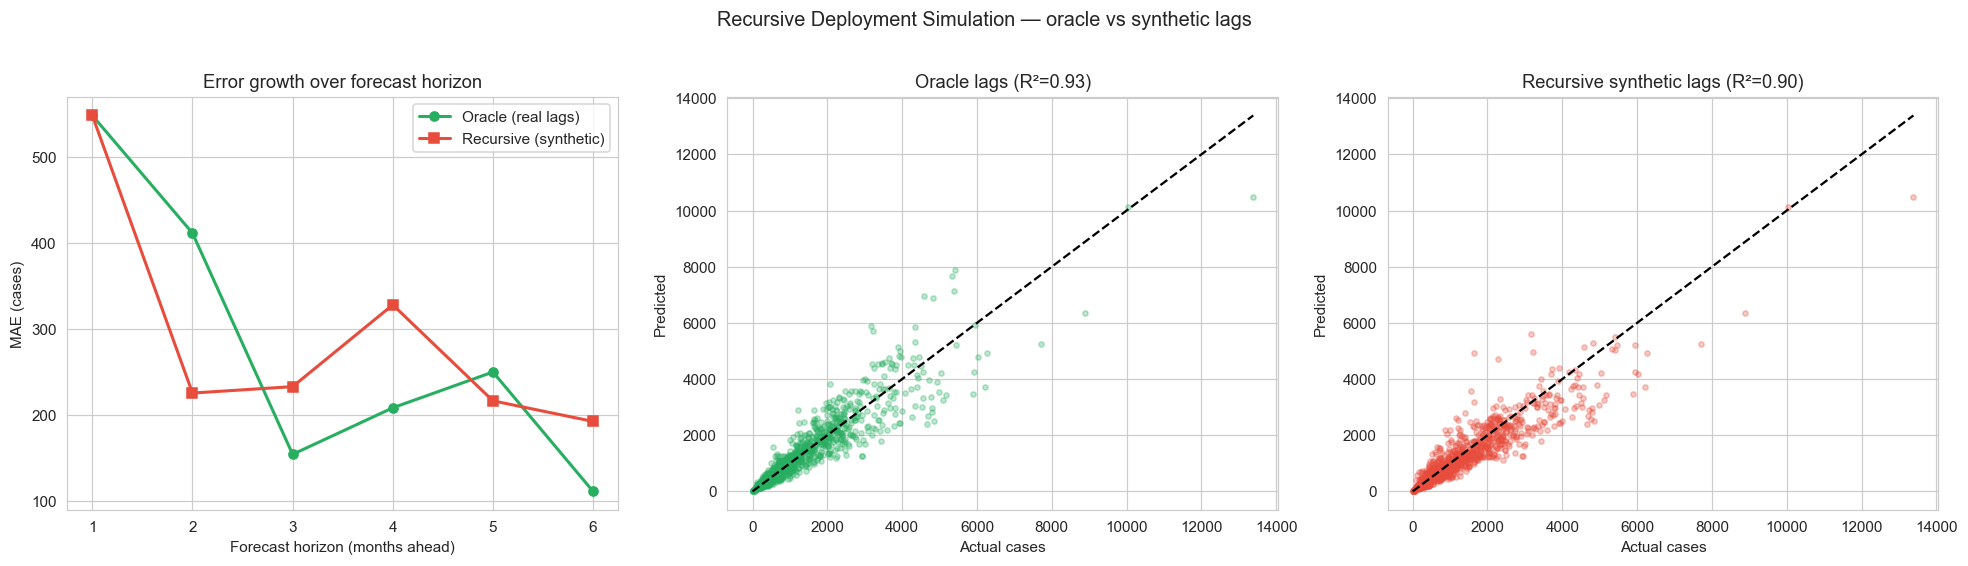

In [6]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
# error growth over horizon
o['h']=o.groupby('district').cumcount()+1; r['h']=r.groupby('district').cumcount()+1
oh=o.groupby('h').apply(lambda g:mean_absolute_error(g.actual,g.pred)); rh=r.groupby('h').apply(lambda g:mean_absolute_error(g.actual,g.pred))
axes[0].plot(oh.index,oh.values,'o-',color='#27ae60',label='Oracle (real lags)',lw=2)
axes[0].plot(rh.index,rh.values,'s-',color='#e74c3c',label='Recursive (synthetic)',lw=2)
axes[0].set_xlabel('Forecast horizon (months ahead)'); axes[0].set_ylabel('MAE (cases)')
axes[0].set_title('Error growth over forecast horizon'); axes[0].legend()
# scatter oracle
axes[1].scatter(o.actual,o.pred,alpha=0.3,s=12,color='#27ae60')
lim=[0,max(o.actual.max(),o.pred.max())]; axes[1].plot(lim,lim,'k--')
axes[1].set_xlabel('Actual cases'); axes[1].set_ylabel('Predicted'); axes[1].set_title(f'Oracle lags (R²={o_r2:.2f})')
# scatter recursive
axes[2].scatter(r.actual,r.pred,alpha=0.3,s=12,color='#e74c3c')
axes[2].plot(lim,lim,'k--')
axes[2].set_xlabel('Actual cases'); axes[2].set_ylabel('Predicted'); axes[2].set_title(f'Recursive synthetic lags (R²={r_r2:.2f})')
plt.suptitle('Recursive Deployment Simulation — oracle vs synthetic lags',fontsize=13,y=1.02)
plt.tight_layout(); plt.show()


## 3 · Feature Importance — what lag_cases does to the ranking

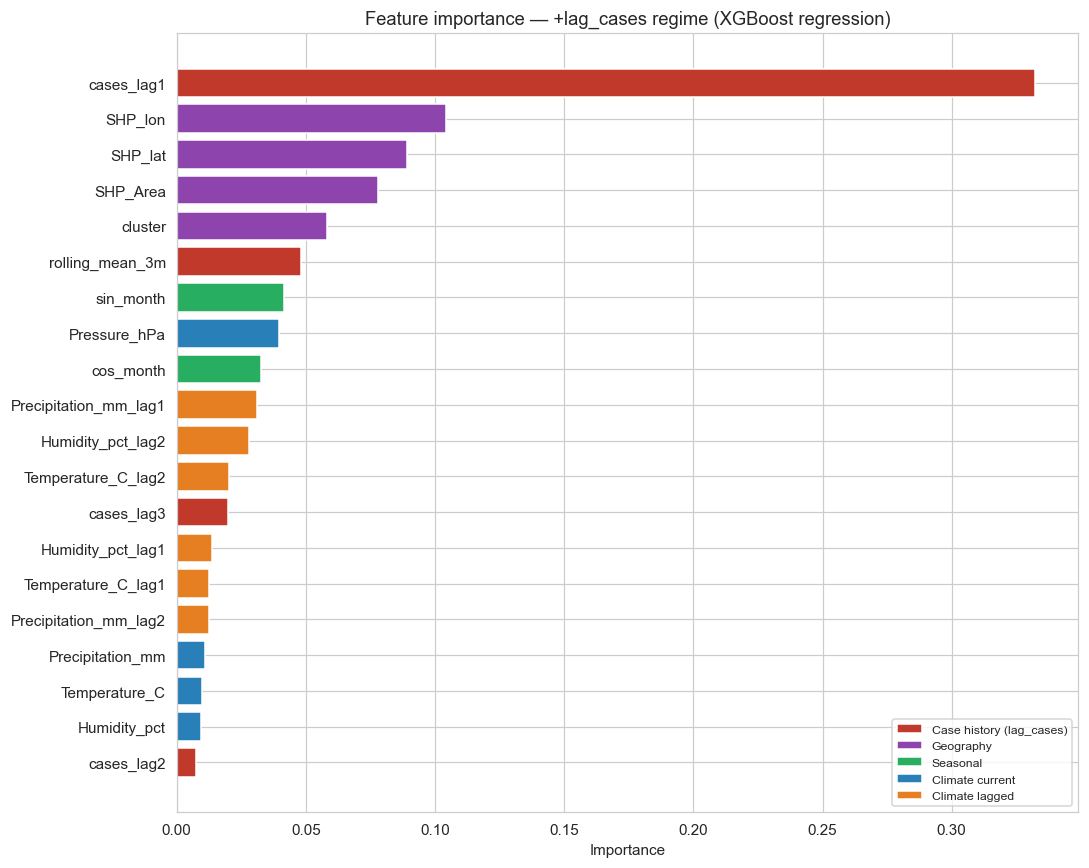

Top 6 features:
  cases_lag1             0.332
  SHP_lon                0.104
  SHP_lat                0.089
  SHP_Area               0.078
  cluster                0.058
  rolling_mean_3m        0.048


In [7]:
def fcol(f):
    if 'cases_lag' in f or 'rolling' in f: return '#c0392b'
    if 'month' in f: return '#27ae60'
    if any(s in f for s in ['lat','lon','Area','cluster']): return '#8e44ad'
    if 'lag' in f: return '#e67e22'
    return '#2980b9'
X=dfm[FEAT_LAGCASES].fillna(dfm[FEAT_LAGCASES].median())
m=xgb.XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,random_state=SEED,verbosity=0)
m.fit(X,dfm['log_incidence'])
imp=pd.Series(m.feature_importances_,index=FEAT_LAGCASES).sort_values()
fig,ax=plt.subplots(figsize=(10,8))
ax.barh(imp.index,imp.values,color=[fcol(f) for f in imp.index])
ax.set_title('Feature importance — +lag_cases regime (XGBoost regression)')
ax.set_xlabel('Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#c0392b',label='Case history (lag_cases)'),
                   Patch(facecolor='#8e44ad',label='Geography'),Patch(facecolor='#27ae60',label='Seasonal'),
                   Patch(facecolor='#2980b9',label='Climate current'),Patch(facecolor='#e67e22',label='Climate lagged')],
          loc='lower right',fontsize=8)
plt.tight_layout(); plt.show()
top=imp.sort_values(ascending=False).head(6)
print('Top 6 features:')
for f,v in top.items(): print(f'  {f:<22} {v:.3f}')


## 4 · Interpretation & Deployment Guidance

**The regime progression confirms the value of each feature group:**

| Regime | Reg R² (TSS) | Clf F1 (KFold) | Reads as |
|---|---|---|---|
| RAW | ~0.10 | ~0.51 | Raw climate alone is weak |
| RAW+ENG | ~0.63 | ~0.72 | Engineering (geography + lags + season) is decisive |
| +lag_cases | ~0.76 | ~0.75 | Case history lifts performance further |

**But the lag_cases gain is partly "borrowed" from autocorrelation.** The
feature-importance plot shows `cases_lag1` / `rolling_mean_3m` dominating — the
model leans on last month's cases, which is trivially predictive because malaria
changes slowly month to month.

**The recursive simulation is the honest deployment number.** When real case
history is unavailable and the model must consume its own predictions as lags:
- Performance degrades from the oracle ceiling
- Error grows with the forecast horizon (each prediction's error feeds the next)

**Deployment recommendation (3-tier strategy):**
1. **Districts with live case reporting** → use `+lag_cases` with real lags (best accuracy).
2. **Districts with sensors but no case data** → use `+lag_cases` in recursive mode,
   seeded by the last known cases, accepting horizon-dependent degradation; OR fall
   back to **RAW+ENG** (no case history needed at all) for a stable climate-only baseline.
3. **New regions entirely** → RAW+ENG only, with a local calibration period
   (consistent with the Leave-One-Region-Out finding).

This gives the thesis a complete, honest performance envelope: the ceiling
(oracle lag_cases), the realistic deployed number (recursive), and the
case-free fallback (RAW+ENG).
